# Моделирование - рекомендации RetailRocket

In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import implicit
from implicit.als import AlternatingLeastSquares
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data'
ROOT_DIR = str(Path.cwd().parent)
MODELS_DIR = os.path.join(ROOT_DIR, 'models')

load_dotenv(os.path.join(ROOT_DIR, '.env'))

S3_BUCKET = os.environ['S3_BUCKET_NAME']
AWS_KEY = os.environ['AWS_ACCESS_KEY_ID']
AWS_SEC = os.environ['AWS_SECRET_ACCESS_KEY']

os.environ['AWS_ACCESS_KEY_ID'] = AWS_KEY
os.environ['AWS_SECRET_ACCESS_KEY'] = AWS_SEC
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'https://storage.yandexcloud.net'

mlflow.set_tracking_uri(f'sqlite:///{ROOT_DIR}/mlflow.db')
mlflow.set_experiment('retailrocket_recsys')
print('mlflow ready')

mlflow ready


## Подготовка данных

In [2]:
events = pd.read_csv(os.path.join(DATA_DIR, 'events.csv'))
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
print('всего событий:', len(events))
print(events['event'].value_counts())

всего событий: 2756101
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [3]:
# view не используем - слишком шумный
WEIGHTS = {'addtocart': 2, 'transaction': 3}

pos = events[events['event'].isin(WEIGHTS)].copy()
pos['weight'] = pos['event'].map(WEIGHTS)
pos = pos.sort_values('timestamp')

user_cnt = pos.groupby('visitorid').size()
active_users = user_cnt[user_cnt >= 2].index
pos = pos[pos['visitorid'].isin(active_users)]

print('активных пользователей:', pos['visitorid'].nunique())
print('уникальных товаров:', pos['itemid'].nunique())
print('положительных событий:', len(pos))

активных пользователей: 16464
уникальных товаров: 19794
положительных событий: 69388


In [4]:
user_ids = pos['visitorid'].unique()
item_ids = pos['itemid'].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}

pos['uidx'] = pos['visitorid'].map(user2idx)
pos['iidx'] = pos['itemid'].map(item2idx)

N_USERS = len(user_ids)
N_ITEMS = len(item_ids)
print(f'матрица {N_USERS} x {N_ITEMS}')

матрица 16464 x 19794


## Train / test split

In [5]:
# последнее событие каждого пользователя - тест
test_idx = pos.groupby('uidx')['timestamp'].idxmax()
test = pos.loc[test_idx]
train = pos.drop(index=test_idx)

print('train:', len(train), 'test:', len(test))
print('покрытие пользователей в train:', train['uidx'].nunique())

train: 52924 test: 16464
покрытие пользователей в train: 16464


In [6]:
data = train['weight'].values.astype(np.float32)
rows = train['uidx'].values
cols = train['iidx'].values
train_matrix = sp.csr_matrix((data, (rows, cols)), shape=(N_USERS, N_ITEMS))
print('ненулевых элементов:', train_matrix.nnz)
print('плотность:', round(train_matrix.nnz / (N_USERS * N_ITEMS) * 100, 4), '%')

ненулевых элементов: 37355
плотность: 0.0115 %


## Метрики оценки

In [7]:
def recall_at_k(actual, recommended, k=10):
    recs = set(recommended[:k])
    return len(set(actual) & recs) / len(set(actual)) if actual else 0.0

def precision_at_k(actual, recommended, k=10):
    recs = recommended[:k]
    return len(set(actual) & set(recs)) / k

def average_precision(actual, recommended, k=10):
    actual_set = set(actual)
    hits, score = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in actual_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(actual), k) if actual else 0.0

def evaluate(test_df, recommend_fn, k=10):
    recalls, precisions, aps = [], [], []
    for uidx, group in test_df.groupby('uidx'):
        actual = group['iidx'].tolist()
        recs = recommend_fn(uidx, k=k)
        recalls.append(recall_at_k(actual, recs, k))
        precisions.append(precision_at_k(actual, recs, k))
        aps.append(average_precision(actual, recs, k))
    return {
        f'recall_at_{k}': round(np.mean(recalls), 4),
        f'precision_at_{k}': round(np.mean(precisions), 4),
        f'map_at_{k}': round(np.mean(aps), 4),
    }

## Бейзлайн - топ популярных товаров

In [8]:
# считаем по train
pop_items = train.groupby('iidx')['weight'].sum().sort_values(ascending=False)
pop_list = pop_items.index.tolist()

def recommend_popular(uidx, k=10):
    # исключаем уже виденные в train
    seen = set(train[train['uidx'] == uidx]['iidx'].tolist())
    return [i for i in pop_list if i not in seen][:k]

metrics_pop = evaluate(test, recommend_popular, k=10)
print('baseline (top popular):', metrics_pop)

baseline (top popular): {'recall_at_10': 0.0042, 'precision_at_10': 0.0004, 'map_at_10': 0.0015}


## ALS

In [9]:
ALS_PARAMS = dict(factors=64, iterations=15, regularization=0.01, random_state=42)
als = AlternatingLeastSquares(**ALS_PARAMS)
als.fit(train_matrix)
print('ALS обучен')

  0%|          | 0/15 [00:00<?, ?it/s]

ALS обучен


In [10]:
def recommend_als(uidx, k=10):
    ids, _ = als.recommend(uidx, train_matrix[uidx], N=k, filter_already_liked_items=True)
    return ids.tolist()

metrics_als = evaluate(test, recommend_als, k=10)
print('ALS:', metrics_als)

ALS: {'recall_at_10': 0.0128, 'precision_at_10': 0.0013, 'map_at_10': 0.0062}


             recall_at_10  precision_at_10  map_at_10
top_popular        0.0042           0.0004     0.0015
als                0.0128           0.0013     0.0062


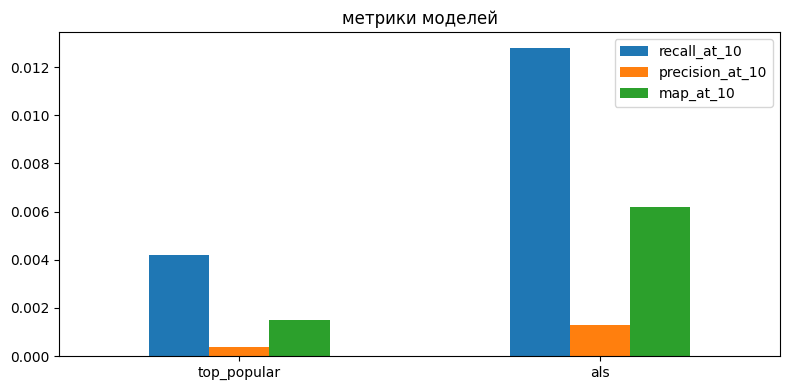

In [11]:
df_metrics = pd.DataFrame([metrics_pop, metrics_als], index=['top_popular', 'als'])
print(df_metrics)

df_metrics.plot(kind='bar', figsize=(8, 4))
plt.title('метрики моделей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
with mlflow.start_run(run_name='top_popular'):
    mlflow.log_param('model', 'top_popular')
    mlflow.log_metrics(metrics_pop)

with mlflow.start_run(run_name='als'):
    mlflow.log_param('model', 'ALS')
    mlflow.log_params(ALS_PARAMS)
    mlflow.log_metrics(metrics_als)
    mlflow.sklearn.log_model(als, artifact_path='als_model', registered_model_name='retailrocket_als')

print('mlflow logged')

2026/06/15 06:31:38 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
Registered model 'retailrocket_als' already exists. Creating a new version of this model...
Created version '2' of model 'retailrocket_als'.
2026/06/15 06:31:40 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


mlflow logged


## i2i - похожие товары

In [13]:
item_factors = als.item_factors
norms = np.linalg.norm(item_factors, axis=1, keepdims=True)
norms[norms == 0] = 1
item_factors_norm = item_factors / norms

N_SIMILAR = 20
SIMILAR_BATCH = 1000
similar_items = {}

for start in range(0, N_ITEMS, SIMILAR_BATCH):
    end = min(start + SIMILAR_BATCH, N_ITEMS)
    batch = item_factors_norm[start:end]
    sims = batch @ item_factors_norm.T
    batch_size = end - start
    sims[np.arange(batch_size), np.arange(start, end)] = -1
    top_k_idx = np.argsort(-sims, axis=1)[:, :N_SIMILAR]
    for i, item_idx in enumerate(range(start, end)):
        similar_items[item_idx] = top_k_idx[i].tolist()

print(f'i2i built for {len(similar_items)} items')
print('пример похожих для первого товара:', similar_items[0][:5])

i2i built for 19794 items
пример похожих для первого товара: [4479, 10595, 875, 77, 19057]


## Сохранение артефактов

In [14]:
MODELS_DIR = os.path.join(ROOT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(MODELS_DIR, 'als_model.pkl'), 'wb') as f:
    pickle.dump(als, f)

with open(os.path.join(MODELS_DIR, 'similar_items.pkl'), 'wb') as f:
    pickle.dump(similar_items, f)

with open(os.path.join(MODELS_DIR, 'mappings.pkl'), 'wb') as f:
    pickle.dump({'user2idx': user2idx, 'item2idx': item2idx, 'idx2item': idx2item}, f)

with open(os.path.join(MODELS_DIR, 'popular_items.pkl'), 'wb') as f:
    pickle.dump(pop_list[:200], f)

print('сохранено в', MODELS_DIR)

сохранено в /home/mle-user/mle-project-sprint-4-v001/models


In [15]:
import boto3

s3 = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=AWS_KEY,
    aws_secret_access_key=AWS_SEC,
)

for fname in ['als_model.pkl', 'similar_items.pkl', 'mappings.pkl', 'popular_items.pkl']:
    s3.upload_file(os.path.join(MODELS_DIR, fname), S3_BUCKET, f'models/{fname}')
    print(f'uploaded {fname}')

print('готово')

uploaded als_model.pkl
uploaded similar_items.pkl
uploaded mappings.pkl
uploaded popular_items.pkl
готово
